In [2]:
from pathlib import Path

import networkx as nx
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
G = nx.read_edgelist(
    "../data/processed/orkut_largest_community.edgelist",
    nodetype=int
)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

Nós: 4785
Arestas: 119891


In [4]:
n = G.number_of_nodes()
m = G.number_of_edges()

print(f"Número de vértices: {n}")
print(f"Número de arestas: {m}")

Número de vértices: 4785
Número de arestas: 119891


In [5]:
degrees = [d for _, d in G.degree()]

degree_min = min(degrees)
degree_max = max(degrees)
degree_mean = np.mean(degrees)

print("Grau mínimo:", degree_min)
print("Grau máximo:", degree_max)
print("Grau médio:", degree_mean)

Grau mínimo: 1
Grau máximo: 425
Grau médio: 50.111180773249735


In [6]:
stats_df = pd.DataFrame({
    "Métrica": [
        "Número de vértices",
        "Número de arestas",
        "Grau mínimo",
        "Grau máximo",
        "Grau médio"
    ],
    "Valor": [
        n,
        m,
        degree_min,
        degree_max,
        round(degree_mean, 2)
    ]
})

stats_df

,Métrica,Valor
0,Número de vértices,4785.00
1,Número de arestas,119891.00
2,Grau mínimo,1.00
3,Grau máximo,425.00
4,Grau médio,50.11


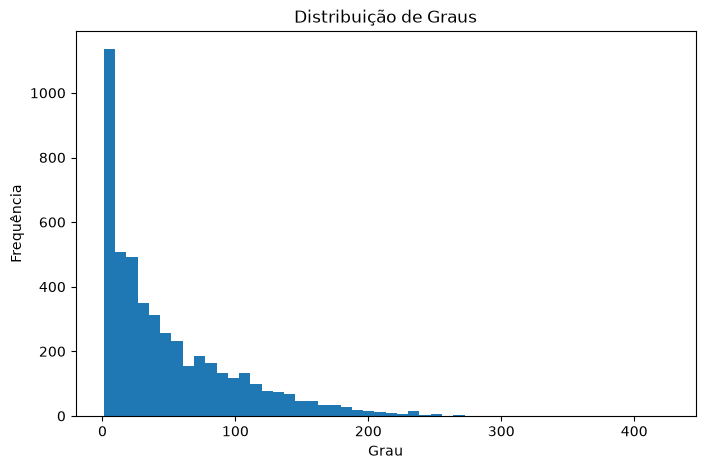

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    degrees,
    bins=50
)

plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de Graus")

plt.show()

plt.savefig("../figures/degree_distribution.png")

In [8]:
plt.figure(figsize=(8,5))

plt.loglog(
    k[1:],
    degree_counts[1:],
    marker='o',
    linestyle='None'
)

plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de Graus (Log-Log)")

plt.tight_layout()

plt.savefig(
    "../figures/degree_distribution_loglog.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'k' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
density = nx.density(G)

print("Densidade:", density)

Densidade: 0.010474745144910062


In [ ]:
components = list(
    nx.connected_components(G)
)

print("Número de componentes:", len(components))

Número de componentes: 1


In [ ]:
component_sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

print(component_sizes[:10])

[4785]


In [ ]:
clustering = nx.average_clustering(G)

print(
    "Coeficiente médio:",
    clustering
)

Coeficiente médio: 0.3129664530934682


In [ ]:
triangles = sum(
    nx.triangles(G).values()
) // 3

print(
    "Número de triângulos:",
    triangles
)

Número de triângulos: 1053848


C:\Users\Admin\AppData\Local\Temp\ipykernel_12816\3690739537.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


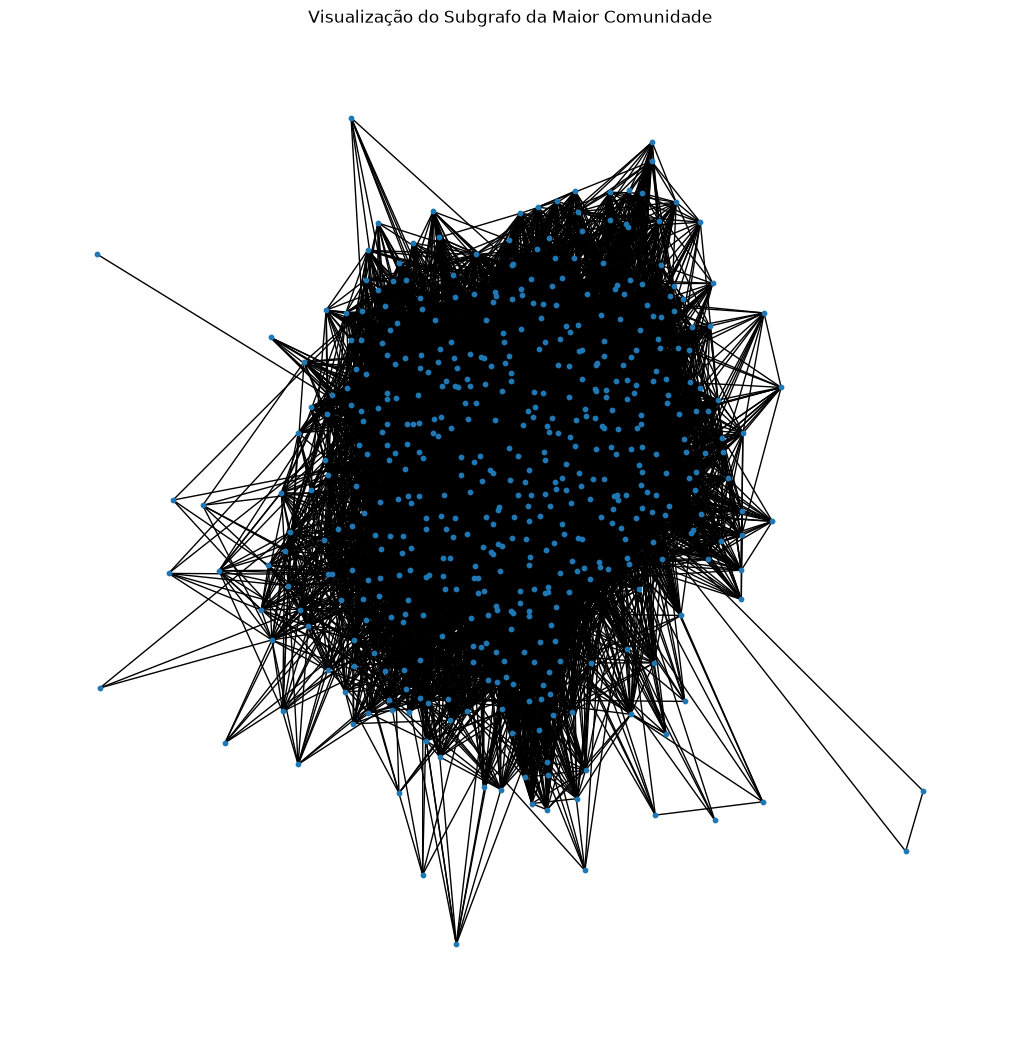

In [ ]:
plt.figure(figsize=(10,10))

pos = nx.spring_layout(
    G_sample,
    seed=42
)

nx.draw(
    G_sample,
    pos,
    node_size=10,
    with_labels=False
)

plt.title(
    "Visualização do Subgrafo da Maior Comunidade"
)

plt.tight_layout()

plt.savefig(
    "../figures/subgraph_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
if nx.is_connected(G) == True:
    diameter = nx.diameter(G)

    radius = nx.radius(G)

    avg_path = nx.average_shortest_path_length(G)

    print("Diâmetro:", diameter)
    print("Raio:", radius)
    print("Comprimento médio:", avg_path)

Diâmetro: 12
Raio: 6
Comprimento médio: 3.283968854733472
